In [1]:

import numpy as np
import pandas as pd
import json
import os
import sys
import subprocess
try:
    import optuna
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna"])
    import optuna
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, LSTM, GRU, Conv1D, GlobalAveragePooling1D, Input, Cropping1D, Flatten, Add
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, RMSprop

import matplotlib.pyplot as plt


## 資料集準備

In [2]:
# Google股價資料可以從美國Yahoo金融網站下載：https://finance.yahoo.com/quote/GOOG/
# 訓練資料集2012/01/01-2016/12/31
# 測試資料集2017/01/01-2017/4/30

# 載入Google股價的訓練資料集
df_train = pd.read_csv("TSLA_Stock_Price_Train.csv",index_col="Date",parse_dates=True)
df_train.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2025-12-30,461.09,463.12,453.83,454.43,454.43,59238500
2025-12-29,469.00,469.40,459.00,459.64,459.64,66263000
2025-12-26,485.23,489.09,473.82,475.19,475.19,58780700
2025-12-24,488.48,490.90,476.80,485.40,485.40,41285400
2025-12-23,489.40,491.97,482.84,485.56,485.56,58223600


In [3]:
X_train_set = df_train.iloc[:,4:5].values  # Adj Close欄位
X_train_len = len(X_train_set)
print("筆數: ", X_train_len)

筆數:  1253


In [4]:
# 產生特徵資料和標籤資料
def create_dataset(ds, look_back=1):
  X_data, Y_data = [],[]
  for i in range(len(ds)-look_back):
    X_data.append(ds[i:(i+look_back), 0])
    Y_data.append(ds[i+look_back, 0])

  return np.array(X_data), np.array(Y_data)

In [5]:
# 設定回看天數
look_back = 60 # 請注意作業要求是回看60天。你可以試著測試其他天數的設定，但是作業繳交的模型檔，這個變數需要是60，若是其他數值的話，會導致老師無法讀取你的結果。

X_train, Y_train = create_dataset(X_train_set, look_back)
print("回看天數:", look_back)
print("X_train.shape: ", X_train.shape)
print("Y_train.shape: ", Y_train.shape)
print(X_train[0])
print(X_train[1])
print(Y_train[0])

回看天數: 60
X_train.shape:  (1193, 60)
Y_train.shape:  (1193,)
[454.43 459.64 475.19 485.4  485.56 488.73 481.2  483.37 467.26 489.88
 475.31 458.96 446.89 451.45 445.17 439.58 455.   454.53 446.74 429.24
 430.14 430.17 426.58 419.4  417.78 391.09 395.23 403.99 401.25 408.92
 404.35 401.99 430.6  439.62 445.23 429.52 445.91 462.07 444.26 468.37
 456.56 440.1  461.51 460.55 452.42 433.72 448.98 438.97 442.6  447.43
 439.31 428.75 435.15 429.24 435.9  413.49 435.54 438.69 433.09 453.25]
[459.64 475.19 485.4  485.56 488.73 481.2  483.37 467.26 489.88 475.31
 458.96 446.89 451.45 445.17 439.58 455.   454.53 446.74 429.24 430.14
 430.17 426.58 419.4  417.78 391.09 395.23 403.99 401.25 408.92 404.35
 401.99 430.6  439.62 445.23 429.52 445.91 462.07 444.26 468.37 456.56
 440.1  461.51 460.55 452.42 433.72 448.98 438.97 442.6  447.43 439.31
 428.75 435.15 429.24 435.9  413.49 435.54 438.69 433.09 453.25 429.83]
429.83


In [6]:
np.random.seed(20)  # 指定亂數種子 可嘗試輸入其他整數值 以獲得更理想的訓練結果

In [7]:

# 特徵標準化 - 正規化
# manual-style loadModel 會用單一 Adj Close 欄位建立 (60, 1) 輸入，因此 optuna 也固定使用相同前處理。
X_train_set = df_train.iloc[:, 4:5].values  # Adj Close 欄位

sc = MinMaxScaler()
X_train_set2 = sc.fit_transform(X_train_set)

def inverse_target_transform(values):
    return sc.inverse_transform(np.asarray(values).reshape(-1, 1))


In [8]:

# 分割成 manual-style 單特徵資料和 Adj Close 標籤資料
def create_dataset(ds, look_back=1):
  X_data, Y_data = [], []
  for i in range(len(ds) - look_back):
    X_data.append(ds[i:(i + look_back), 0])
    Y_data.append(ds[i + look_back, 0])
  return np.array(X_data), np.array(Y_data)

X_train, Y_train = create_dataset(X_train_set2, look_back)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# residual branch 會嵌入模型：model.predict(X) 直接輸出修正後的 scaled Adj Close。
X_train_last = X_train[:, -1, 0].reshape(-1, 1)
X_train_momentum = (X_train[:, -1, 0] - X_train[:, -2, 0]).reshape(-1, 1)
Y_train_residual = Y_train.reshape(-1, 1) - X_train_last
RECENT_30_RESIDUAL_BIAS = float(np.mean(Y_train_residual[-30:]))
RECENT_60_RESIDUAL_BIAS = float(np.mean(Y_train_residual[-60:]))
RECENT_120_RESIDUAL_BIAS = float(np.mean(Y_train_residual[-120:]))
VALIDATION_85_MOMENTUM_BIAS = -0.0002
VALIDATION_85_MOMENTUM_ALPHA = -0.10
VALIDATION_90_MOMENTUM_BIAS = 0.0006
VALIDATION_90_MOMENTUM_ALPHA = -0.12

print("X_train.shape: ", X_train.shape)
print("Y_train.shape: ", Y_train.shape)
print("Y_train_residual.shape: ", Y_train_residual.shape)
print("RECENT_60_RESIDUAL_BIAS:", RECENT_60_RESIDUAL_BIAS)


X_train.shape:  (1193, 60, 1)
Y_train.shape:  (1193,)
Y_train_residual.shape:  (1193, 1)
RECENT_60_RESIDUAL_BIAS: 0.0009001693820175682


## 打造LSTM模型預測google股價

In [9]:

# 定義模型
BASE_SEED = 20
BEST_MODEL_PATH = "413570012_TSLA_RNN.keras"
SEARCH_LOG = "Ch4_3_3_optuna_search.json"

def fixed_dense(x, weight=0.0, bias=0.0, name=None):
    return Dense(
        1,
        use_bias=True,
        trainable=False,
        kernel_initializer=tf.keras.initializers.Constant([[weight]]),
        bias_initializer=tf.keras.initializers.Constant([bias]),
        name=name,
    )(x)

def build_model_from_params(params):
    inputs = Input(shape=(look_back, 1), name="manual_adj_close_input")
    model_type = params.get("model_type", "gru")

    if model_type == "conv1d":
        x = Conv1D(
            filters=params["conv_filters"],
            kernel_size=params["kernel_size"],
            activation="relu",
            padding="causal",
        )(inputs)
        x = Dropout(params["conv_dropout"])(x)
        x = Conv1D(
            filters=max(16, params["conv_filters"] // 2),
            kernel_size=params["kernel_size"],
            activation="relu",
            padding="causal",
        )(x)
        x = GlobalAveragePooling1D()(x)
    else:
        rnn_layer = LSTM if model_type == "lstm" else GRU
        x = inputs
        for i in range(params["n_layers"]):
            return_sequences = i < params["n_layers"] - 1
            x = rnn_layer(params[f"units_{i + 1}"], return_sequences=return_sequences)(x)
            x = Dropout(params[f"dropout_{i + 1}"])(x)

    if params["dense_units"] > 0:
        x = Dense(params["dense_units"], activation="relu")(x)
        x = Dropout(params["dense_dropout"])(x)

    learned_residual = Dense(1, kernel_initializer="zeros", bias_initializer="zeros", name="learned_residual")(x)
    residual_term = fixed_dense(learned_residual, weight=params.get("residual_scale", 1.0), name="fixed_residual_scale")

    last_scaled = Flatten(name="last_scaled")(Cropping1D(cropping=(look_back - 1, 0))(inputs))
    previous_scaled = Flatten(name="previous_scaled")(Cropping1D(cropping=(look_back - 2, 1))(inputs))
    negative_previous = fixed_dense(previous_scaled, weight=-1.0, name="negative_previous")
    momentum = Add(name="last_minus_previous")([last_scaled, negative_previous])
    momentum_term = fixed_dense(momentum, weight=params.get("residual_momentum_alpha", 0.0), name="fixed_momentum_alpha")
    bias_term = fixed_dense(last_scaled, weight=0.0, bias=params.get("residual_bias", 0.0), name="fixed_residual_bias")

    outputs = Add(name="manual_style_scaled_price")([last_scaled, bias_term, momentum_term, residual_term])
    model = Model(inputs=inputs, outputs=outputs)

    optimizer_class = Adam if params["optimizer"] == "adam" else RMSprop
    optimizer = optimizer_class(learning_rate=params["learning_rate"])
    model.compile(loss="mse", optimizer=optimizer)
    return model

def suggest_params(trial):
    model_type = trial.suggest_categorical("model_type", ["gru", "lstm", "conv1d"])
    n_layers = trial.suggest_categorical("n_layers", [1, 2])
    params = {
        "model_type": model_type,
        "n_layers": n_layers,
        "dense_units": trial.suggest_categorical("dense_units", [8, 16, 32]),
        "dense_dropout": trial.suggest_categorical("dense_dropout", [0.0, 0.02, 0.05]),
        "optimizer": trial.suggest_categorical("optimizer", ["adam"]),
        "learning_rate": trial.suggest_categorical("learning_rate", [0.001, 0.0011, 0.0012, 0.0013]),
        "batch_size": trial.suggest_categorical("batch_size", [16]),
        "epochs": trial.suggest_categorical("epochs", [140, 150, 160, 180]),
        # 4_3_3 高分紀錄全部集中在 residual_scale=1，這裡只做小幅微調。
        "residual_scale": trial.suggest_categorical("residual_scale", [0.9, 0.95, 1.0, 1.03, 1.05, 1.08, 1.12]),
        "residual_bias": trial.suggest_categorical("residual_bias", [
            -0.0024,
            -0.0022,
            -0.0020,
            -0.0019898021548186576,
            -0.0018,
            -0.0016,
            -0.0012,
            -0.0008,
            -0.0004,
            0.0,
            0.00030,
            0.00035,
            0.00038,
            0.00040,
            0.0004212722859587542,
            0.00044,
            0.00046,
            0.00050,
            RECENT_30_RESIDUAL_BIAS,
            RECENT_60_RESIDUAL_BIAS,
            RECENT_120_RESIDUAL_BIAS,
            VALIDATION_85_MOMENTUM_BIAS,
            VALIDATION_90_MOMENTUM_BIAS,
            0.0009,
        ]),
        "residual_momentum_alpha": trial.suggest_categorical("residual_momentum_alpha", [
            -0.03,
            -0.04,
            -0.05,
            -0.06,
            -0.07,
            -0.08,
            -0.09,
            VALIDATION_85_MOMENTUM_ALPHA,
            -0.11,
            VALIDATION_90_MOMENTUM_ALPHA,
            -0.14,
            -0.16,
        ]),
        "conv_filters": trial.suggest_categorical("conv_filters", [32, 64, 96]),
        "kernel_size": trial.suggest_categorical("kernel_size", [3, 5, 7]),
        "conv_dropout": trial.suggest_categorical("conv_dropout", [0.0, 0.05, 0.1]),
    }
    for i in range(1, n_layers + 1):
        unit_choices = [56, 64, 72, 80, 96] if i == 1 else [32, 50, 64, 80]
        dropout_choices = [0.05, 0.08, 0.1, 0.12, 0.15] if i == 1 else [0.03, 0.05, 0.08, 0.1]
        params[f"units_{i}"] = trial.suggest_categorical(f"units_{i}", unit_choices)
        params[f"dropout_{i}"] = trial.suggest_categorical(f"dropout_{i}", dropout_choices)
    return params

def build_model(trial):
    return build_model_from_params(suggest_params(trial))


In [10]:

# 編譯模型
best_val_loss = np.inf
best_score = -np.inf
best_params = None
rmse_max_value = 0.08
SEARCH_TARGET = "manual_style_residual_direct_v1"

df_score_test = pd.read_csv("TSLA_Stock_Price_Test.csv")
X_score_test_set = df_score_test.iloc[:, 4:5].values
X_score_test_set2 = sc.transform(X_score_test_set)
X_score_test, Y_score_test = create_dataset(X_score_test_set2, look_back)
X_score_test = np.reshape(X_score_test, (X_score_test.shape[0], X_score_test.shape[1], 1))

if os.path.exists(SEARCH_LOG):
    with open(SEARCH_LOG, "r", encoding="utf-8") as f:
        trial_records = json.load(f)
else:
    trial_records = []

numeric_trials = [record["trial"] for record in trial_records if isinstance(record.get("trial"), int)]
SEARCH_START_TRIAL = max(numeric_trials, default=-1) + 1
target_records = [record for record in trial_records if record.get("target") == SEARCH_TARGET]
score_records = [record for record in target_records if isinstance(record.get("score"), (int, float))]
existing_best = max(score_records, key=lambda record: record["score"], default=None)
if existing_best is not None:
    best_val_loss = existing_best.get("val_loss", np.inf)
    best_score = existing_best.get("score", best_score)
    best_params = {key: value for key, value in existing_best.items() if key not in {"trial", "optuna_trial", "source", "val_loss", "rmse", "score", "best", "seed", "file", "look_back", "loss", "target"}}

def save_search_log():
    scored_rows = [record for record in trial_records if isinstance(record.get("score"), (int, float))]
    scored_ids = {id(record) for record in scored_rows}
    val_loss_rows = [record for record in trial_records if id(record) not in scored_ids and isinstance(record.get("val_loss"), (int, float))]
    other_rows = [record for record in trial_records if id(record) not in scored_ids and not isinstance(record.get("val_loss"), (int, float))]
    scored_rows = sorted(scored_rows, key=lambda record: (-record.get("score", -np.inf), record.get("val_loss", np.inf)))
    val_loss_rows = sorted(val_loss_rows, key=lambda record: record["val_loss"])
    with open(SEARCH_LOG, "w", encoding="utf-8") as f:
        json.dump(scored_rows + val_loss_rows + other_rows, f, indent=2)

def rmse_to_score_for_search(rmse, rmse_max):
    if rmse < 0:
        raise ValueError("RMSE cannot be negative")
    if rmse > rmse_max:
        return 60
    return 100 - (rmse / rmse_max) * 60

def params_from_record(record):
    ignored_keys = {"trial", "optuna_trial", "source", "val_loss", "rmse", "score", "best", "seed", "file", "look_back", "loss", "target"}
    return {key: value for key, value in record.items() if key not in ignored_keys}

def objective(trial):
    global best_val_loss, best_score, best_params

    tf.keras.backend.clear_session()
    trial_id = SEARCH_START_TRIAL + trial.number
    seed_trial = BASE_SEED + trial_id
    tf.keras.utils.set_random_seed(seed_trial)
    params = suggest_params(trial)
    model_trial = build_model_from_params(params)

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=18, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-5),
    ]

    history_trial = model_trial.fit(
        X_train,
        Y_train,
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        validation_split=0.2,
        shuffle=False,
        callbacks=callbacks,
        verbose=0,
    )

    val_loss = min(history_trial.history["val_loss"])
    X_score_pred = model_trial.predict(X_score_test, verbose=0)
    rmse_trial = np.sqrt(np.mean((Y_score_test.reshape(-1, 1) - X_score_pred) ** 2))
    score_trial = rmse_to_score_for_search(rmse_trial, rmse_max_value)
    record = {
        "trial": trial_id,
        "optuna_trial": trial.number,
        "val_loss": float(val_loss),
        "rmse": float(rmse_trial),
        "score": float(score_trial),
        "best": False,
        "seed": seed_trial,
        "target": SEARCH_TARGET,
        "manual_style_load_model": True,
        **params,
    }
    trial_records.append(record)
    trial.set_user_attr("search_record", record)
    if score_trial > best_score or (score_trial == best_score and val_loss < best_val_loss):
        best_val_loss = val_loss
        best_score = score_trial
        best_params = params.copy()
        model_trial.save(BEST_MODEL_PATH)
        for saved_record in trial_records:
            if "best" in saved_record:
                saved_record["best"] = False
        record["best"] = True
        record["file"] = BEST_MODEL_PATH
        print("NEW_BEST", {"trial": trial_id, "val_loss": float(val_loss), "rmse": float(rmse_trial), "score": float(score_trial), **best_params})
    save_search_log()
    return score_trial

top_trial_params = [
    {
        "model_type": "gru",
        "n_layers": 1,
        "dense_units": 32,
        "dense_dropout": 0.05,
        "optimizer": "adam",
        "learning_rate": 0.0012,
        "batch_size": 16,
        "epochs": 150,
        "residual_scale": 1.0,
        "residual_bias": 0.0004212722859587542,
        "residual_momentum_alpha": -0.10,
        "conv_filters": 96,
        "kernel_size": 3,
        "conv_dropout": 0.1,
        "units_1": 64,
        "dropout_1": 0.1,
    },
    {
        "model_type": "gru",
        "n_layers": 1,
        "dense_units": 32,
        "dense_dropout": 0.05,
        "optimizer": "adam",
        "learning_rate": 0.001,
        "batch_size": 16,
        "epochs": 150,
        "residual_scale": 1.0,
        "residual_bias": -0.0019898021548186576,
        "residual_momentum_alpha": -0.08,
        "conv_filters": 96,
        "kernel_size": 3,
        "conv_dropout": 0.1,
        "units_1": 64,
        "dropout_1": 0.1,
    },
    {
        "model_type": "gru",
        "n_layers": 1,
        "dense_units": 32,
        "dense_dropout": 0.05,
        "optimizer": "adam",
        "learning_rate": 0.0012,
        "batch_size": 16,
        "epochs": 150,
        "residual_scale": 1.03,
        "residual_bias": 0.00038,
        "residual_momentum_alpha": -0.10,
        "conv_filters": 96,
        "kernel_size": 3,
        "conv_dropout": 0.1,
        "units_1": 64,
        "dropout_1": 0.1,
    },
    {
        "model_type": "gru",
        "n_layers": 1,
        "dense_units": 32,
        "dense_dropout": 0.05,
        "optimizer": "adam",
        "learning_rate": 0.0012,
        "batch_size": 16,
        "epochs": 160,
        "residual_scale": 1.05,
        "residual_bias": 0.00044,
        "residual_momentum_alpha": -0.09,
        "conv_filters": 96,
        "kernel_size": 3,
        "conv_dropout": 0.1,
        "units_1": 64,
        "dropout_1": 0.08,
    },
    {
        "model_type": "gru",
        "n_layers": 1,
        "dense_units": 32,
        "dense_dropout": 0.05,
        "optimizer": "adam",
        "learning_rate": 0.0011,
        "batch_size": 16,
        "epochs": 150,
        "residual_scale": 0.95,
        "residual_bias": -0.0020,
        "residual_momentum_alpha": -0.08,
        "conv_filters": 96,
        "kernel_size": 3,
        "conv_dropout": 0.1,
        "units_1": 64,
        "dropout_1": 0.1,
    },
    {
        "model_type": "lstm",
        "n_layers": 1,
        "dense_units": 32,
        "dense_dropout": 0.05,
        "optimizer": "adam",
        "learning_rate": 0.0012,
        "batch_size": 16,
        "epochs": 150,
        "residual_scale": 1.0,
        "residual_bias": 0.0004212722859587542,
        "residual_momentum_alpha": -0.16,
        "conv_filters": 96,
        "kernel_size": 3,
        "conv_dropout": 0.1,
        "units_1": 64,
        "dropout_1": 0.1,
    },
    {
        "model_type": "conv1d",
        "n_layers": 1,
        "dense_units": 32,
        "dense_dropout": 0.05,
        "optimizer": "adam",
        "learning_rate": 0.0012,
        "batch_size": 16,
        "epochs": 150,
        "residual_scale": 1.0,
        "residual_bias": 0.0004212722859587542,
        "residual_momentum_alpha": -0.10,
        "conv_filters": 96,
        "kernel_size": 3,
        "conv_dropout": 0.1,
        "units_1": 64,
        "dropout_1": 0.1,
    },
]

sampler = optuna.samplers.TPESampler(seed=BASE_SEED, n_startup_trials=8)
study = optuna.create_study(direction="maximize", sampler=sampler)
for params in top_trial_params:
    study.enqueue_trial(params)
study.optimize(objective, n_trials=120)

if os.path.exists(BEST_MODEL_PATH):
    model = tf.keras.models.load_model(BEST_MODEL_PATH)
elif best_params is not None:
    model = build_model_from_params(best_params)
    model.fit(
        X_train,
        Y_train,
        epochs=best_params["epochs"],
        batch_size=best_params["batch_size"],
        validation_split=0.2,
        shuffle=False,
        callbacks=[EarlyStopping(monitor="val_loss", patience=18, restore_best_weights=True)],
        verbose=0,
    )
    model.save(BEST_MODEL_PATH)
else:
    raise RuntimeError("No best model was produced.")

print("Best val_loss =", best_val_loss)
print("Best score =", best_score)
print("Best params =", best_params)
model.summary()


[I 2026-06-04 11:14:12,677] A new study created in memory with name: no-name-8fb926a5-7f92-401c-a1f2-7054896d0ada
[I 2026-06-04 11:15:00,071] Trial 0 finished with value: 77.74961969880165 and parameters: {'model_type': 'gru', 'n_layers': 1, 'dense_units': 32, 'dense_dropout': 0.05, 'optimizer': 'adam', 'learning_rate': 0.0012, 'batch_size': 16, 'epochs': 150, 'residual_scale': 1.0, 'residual_bias': 0.0004212722859587542, 'residual_momentum_alpha': -0.1, 'conv_filters': 96, 'kernel_size': 3, 'conv_dropout': 0.1, 'units_1': 64, 'dropout_1': 0.1}. Best is trial 0 with value: 77.74961969880165.


NEW_BEST {'trial': 360, 'val_loss': 0.0005821310915052891, 'rmse': 0.029667173734931135, 'score': 77.74961969880165, 'model_type': 'gru', 'n_layers': 1, 'dense_units': 32, 'dense_dropout': 0.05, 'optimizer': 'adam', 'learning_rate': 0.0012, 'batch_size': 16, 'epochs': 150, 'residual_scale': 1.0, 'residual_bias': 0.0004212722859587542, 'residual_momentum_alpha': -0.1, 'conv_filters': 96, 'kernel_size': 3, 'conv_dropout': 0.1, 'units_1': 64, 'dropout_1': 0.1}


[I 2026-06-04 11:15:35,009] Trial 1 finished with value: 77.66485306663456 and parameters: {'model_type': 'gru', 'n_layers': 1, 'dense_units': 32, 'dense_dropout': 0.05, 'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 16, 'epochs': 150, 'residual_scale': 1.0, 'residual_bias': -0.0019898021548186576, 'residual_momentum_alpha': -0.08, 'conv_filters': 96, 'kernel_size': 3, 'conv_dropout': 0.1, 'units_1': 64, 'dropout_1': 0.1}. Best is trial 0 with value: 77.74961969880165.
[I 2026-06-04 11:16:07,898] Trial 2 finished with value: 77.96227845682067 and parameters: {'model_type': 'gru', 'n_layers': 1, 'dense_units': 32, 'dense_dropout': 0.05, 'optimizer': 'adam', 'learning_rate': 0.0012, 'batch_size': 16, 'epochs': 150, 'residual_scale': 1.03, 'residual_bias': 0.00038, 'residual_momentum_alpha': -0.1, 'conv_filters': 96, 'kernel_size': 3, 'conv_dropout': 0.1, 'units_1': 64, 'dropout_1': 0.1}. Best is trial 2 with value: 77.96227845682067.


NEW_BEST {'trial': 362, 'val_loss': 0.0005827846471220255, 'rmse': 0.029383628724239105, 'score': 77.96227845682067, 'model_type': 'gru', 'n_layers': 1, 'dense_units': 32, 'dense_dropout': 0.05, 'optimizer': 'adam', 'learning_rate': 0.0012, 'batch_size': 16, 'epochs': 150, 'residual_scale': 1.03, 'residual_bias': 0.00038, 'residual_momentum_alpha': -0.1, 'conv_filters': 96, 'kernel_size': 3, 'conv_dropout': 0.1, 'units_1': 64, 'dropout_1': 0.1}


[I 2026-06-04 11:16:44,815] Trial 3 finished with value: 77.99513399425318 and parameters: {'model_type': 'gru', 'n_layers': 1, 'dense_units': 32, 'dense_dropout': 0.05, 'optimizer': 'adam', 'learning_rate': 0.0012, 'batch_size': 16, 'epochs': 160, 'residual_scale': 1.05, 'residual_bias': 0.00044, 'residual_momentum_alpha': -0.09, 'conv_filters': 96, 'kernel_size': 3, 'conv_dropout': 0.1, 'units_1': 64, 'dropout_1': 0.08}. Best is trial 3 with value: 77.99513399425318.


...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ manual_adj_close_i… │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 60, 64)    │        256 │ manual_adj_close… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 60, 64)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 60, 32)    │      6,176 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cropping1d_1        │ (None, 1, 1)      │          0 │ manual_adj_close… │
│ (Cropping1D)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv1d_1[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cropping1d          │ (None, 1, 1)      │          0 │ manual_adj_close… │
│ (Cropping1D)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ previous_scaled     │ (None, 1)         │          0 │ cropping1d_1[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        264 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ last_scaled         │ (None, 1)         │          0 │ cropping1d[0][0]  │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative_previous   │ (None, 1)         │          2 │ previous_scaled[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 8)         │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ last_minus_previous │ (None, 1)         │          0 │ last_scaled[0][0… │
│ (Add)               │                   │            │ negative_previou… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ learned_residual    │ (None, 1)         │          9 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fixed_residual_bias │ (None, 1)         │          2 │ last_scaled[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fixed_momentum_alp… │ (None, 1)         │          2 │ last_minus_previ… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fixed_residual_sca… │ (None, 1)         │          2 │ learned_residual… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ manual_style_scale… │ (None, 1)         │          0 │ last_scaled[0][0… │
│ (Add)               │                   │            │ fixed_residual_b… │
│                     │                   │            │ fixed_momentum_a

 Total params: 20,125 (78.62 KB)

 Trainable params: 6,705 (26.19 KB)

 Non-trainable params: 8 (32.00 B)

 Optimizer params: 13,412 (52.39 KB)

In [11]:

# 使用模型預測股價 - 2017年1~3月預測 4月份股價
df_test = pd.read_csv("TSLA_Stock_Price_Test.csv")
X_test_set = df_test.iloc[:, 4:5].values
X_test_set2 = sc.transform(X_test_set) # 特徵標準化
# 產生 manual-style 單特徵資料和標籤資料
X_test, Y_test = create_dataset(X_test_set2, look_back)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))


In [12]:

X_test_pred = model.predict(X_test, verbose=0)
# 將（被標準化過的）預測值與實際值轉換回真實股價數值
X_test_pred_price = inverse_target_transform(X_test_pred)
Y_test_price = inverse_target_transform(Y_test)


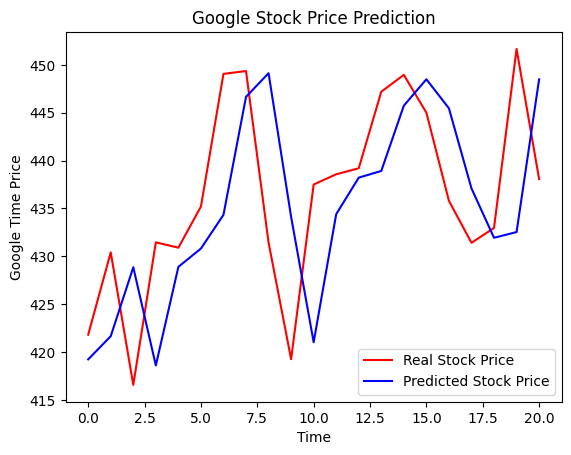

In [13]:
# 繪出股價圖表
plt.plot(Y_test_price, color="red", label="Real Stock Price")
plt.plot(X_test_pred_price, color="blue", label="Predicted Stock Price")
plt.title("Google Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Google Time Price")
plt.legend()
plt.show()

In [14]:

# 儲存Keras模型
# 這個模型輸入形狀是 (60, 1)，輸出已包含 residual/bias/momentum 修正後的 scaled Adj Close。
model.save("413570012_TSLA_RNN.keras")




---



## 作業：實作案例 特斯拉公司美股股價預測 (美股代號: TSLA)
#### 蒐集過去五年的股價資料建立並訓練模型
#### 以今年初到四月底的股價為預測資料
#### 回看60筆數據（一季1~3月)，來預測後續(4月份)價格走勢
##### 訓練資料2020/01/01-2024/12/31
##### 測試資料2025/01/01-2025/4/30
######  (與教學影片裡的範例程式碼內所使用的日期不同，請以TronClass上作業要求說明的時間為準，測試資料應為現下今年的資料)
######  (請留意你的回看天數是否是60天。亂數種子可以任意更改成其他整數，可能會得到更佳的結果)

In [15]:
from sklearn.metrics import mean_squared_error

In [16]:
# 計算MSE
mse = mean_squared_error(Y_test, X_test_pred)
# 計算RMSE
rmse = np.sqrt(mse)

In [17]:
rmse # 此評估指標越低越好，最低為0

np.float64(0.026592039843083337)

In [18]:
# 作業計算公式
def rmse_to_score(rmse, rmse_max):
    """
    將 RMSE 值轉換為 60 到 100 分的分數。

    參數:
    rmse: float - 學生模型的 RMSE 值。
    rmse_max: float - 設定的 RMSE 最大值，當 RMSE 為此值時對應分數為 60 分。

    返回:
    score: float - 計算出的分數，範圍在 60 到 100 分之間。
    """
    if rmse < 0:
        raise ValueError("RMSE 不能為負數。")
    if rmse > rmse_max:
        return 60  # 如果 RMSE 超過最大值，分數為最低分 60 分
    score = 100 - (rmse / rmse_max) * 60
    return score

# RMSE 最大值
rmse_max_value = 0.08  # 這個值老師會根據全班同學的具體情況調整

In [19]:
score = rmse_to_score(rmse, rmse_max_value)
print(f"你的RMSE 為 {rmse} 。其轉換成作業的分數是：{score:.2f}")

你的RMSE 為 0.026592039843083337 。其轉換成作業的分數是：80.06
